## Setup and Model Initialization
We initialize each model using its best-performing tuned configuration from our previous experiments.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Load data
df = pd.read_csv("../data/diabetes_cleaned.csv")
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

# 2. Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Instantiate best tuned models (Note: probability=True enabled on SVC for ROC-AUC calculation)
tuned_models = {
    "Naïve Bayes": GaussianNB(var_smoothing=1e-9),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Support Vector Machine": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(penalty="elasticnet", l1_ratio=0.0, C=1.0, solver="saga", max_iter=5000, random_state=42),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5, weights="uniform"),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=3, random_state=42)
}

print("Setup completed successfully.")

Setup completed successfully.


## Part L - Comprehensive Metric Evaluation Table
We build the required comparison table containing Accuracy, Precision, Recall, F1-Score, and ROC-AUC for all six models.

In [2]:
results = []

for name, model in tuned_models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict class & probability
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

# Format and display metric table
metrics_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
display(metrics_df.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "F1-Score": "{:.4f}", "ROC-AUC": "{:.4f}"
}))

c:\Users\User\Desktop\samsung-ml-regression-tasks\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\User\Desktop\samsung-ml-regression-tasks\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
5,Random Forest,0.8636,0.8113,0.7963,0.8037,0.9300
2,Support Vector Machine,0.8377,0.7636,0.7778,0.7706,0.8974
1,Decision Tree,0.8506,0.7627,0.8333,0.7965,0.8847
4,K-Nearest Neighbours,0.8117,0.7358,0.7222,0.7290,0.8631
3,Logistic Regression,0.7078,0.5882,0.5556,0.5714,0.8263
0,Naïve Bayes,0.7273,0.6034,0.6481,0.6250,0.8017


## Plotting Confusion Matrices
Visualizing the confusion matrix for each model allows us to directly count False Negatives and False Positives.

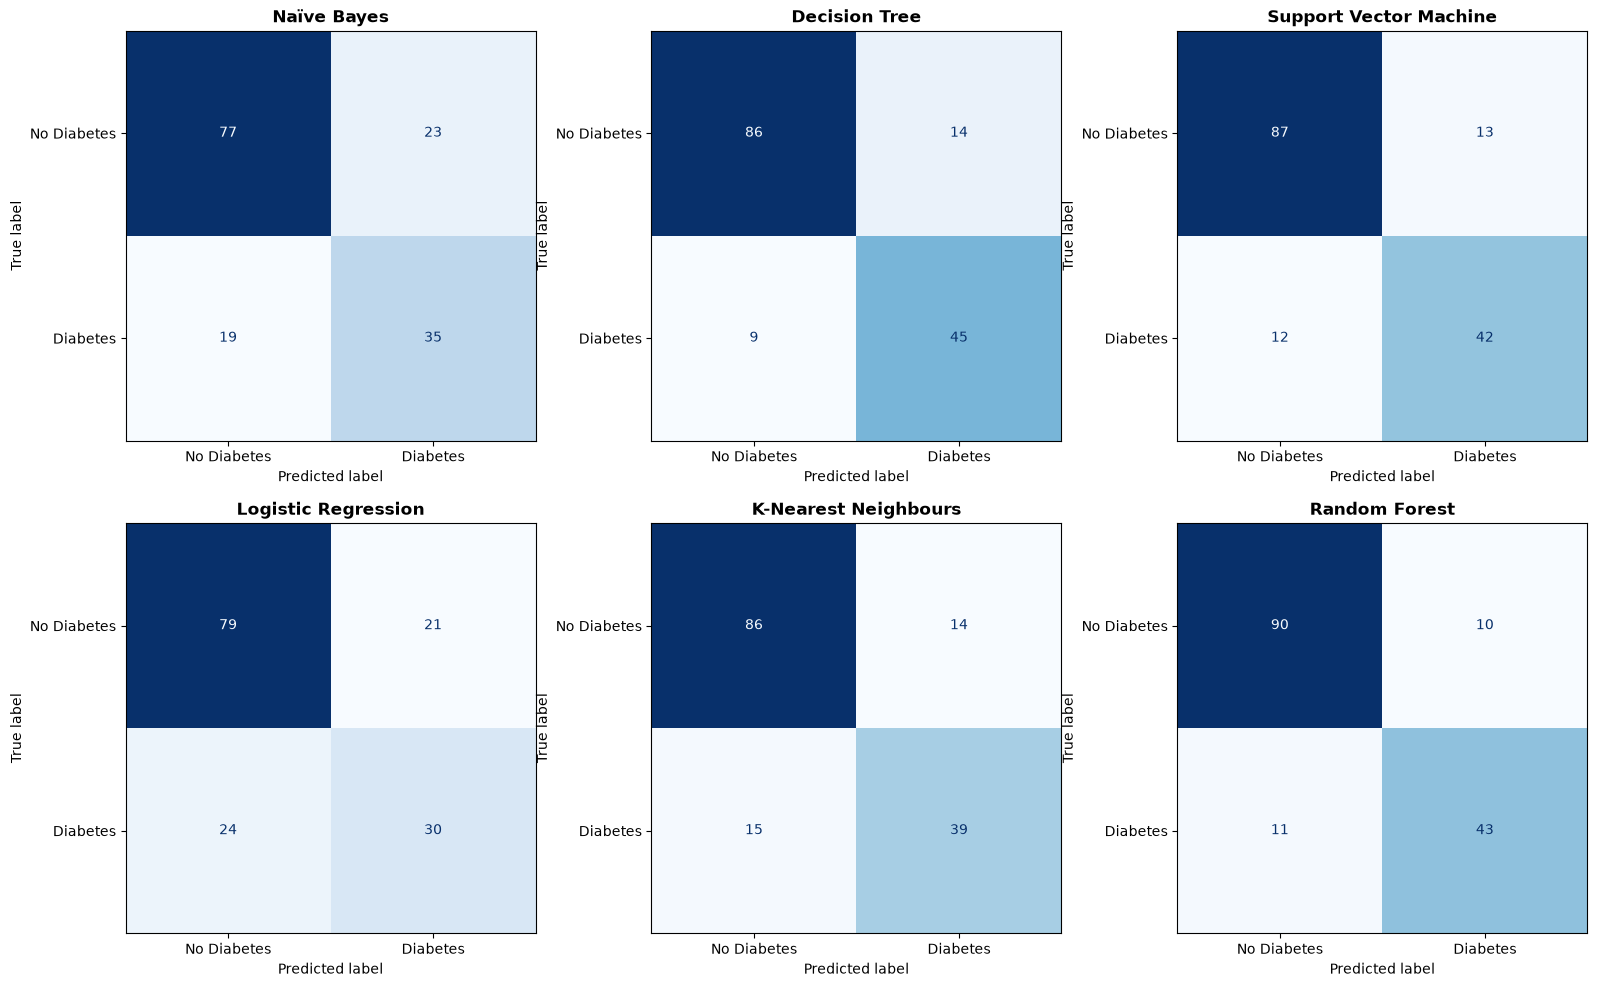

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(tuned_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False)
    axes[idx].set_title(f"{name}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

### Part M: Understanding the Confusion Matrix in a Medical Context

In a medical screening context for diabetes:
* **False Positive (FP):** The model predicts a patient has diabetes when they do not. 
  * *Clinical Consequence:* Unnecessary stress, follow-up tests, and administrative cost.
* **False Negative (FN):** The model predicts a patient does **NOT** have diabetes when they **ACTUALLY DO**. 
  * *Clinical Consequence:* Delayed medical intervention, progression of underlying tissue/organ damage, and potentially severe long-term complications.

> **Clinical Insight:** False Negatives are drastically more dangerous than False Positives in medical diagnostics. Therefore, **Recall** (sensitivity)—which directly minimizes False Negatives—and **ROC-AUC** are far more critical evaluation metrics than raw Accuracy alone.

---

### Part N: Model Critique & Answers

1. **Which model has the highest accuracy?** 
   **Random Forest** with an accuracy of **86.36%** (0.8636).
2. **Which has the highest recall?** 
   **Decision Tree** with a recall of **83.33%** (0.8333).
3. **Which has the highest precision?** 
   **Random Forest** with a precision of **81.13%** (0.8113).
4. **Which has the highest F1-score?** 
   **Random Forest** with an F1-score of **80.37%** (0.8037).
5. **Which has the highest ROC-AUC?** 
   **Random Forest** with an outstanding ROC-AUC of **0.9300**.
6. **Which model produces the fewest false negatives?** 
   **Decision Tree**, producing only **9 False Negatives** (compared to 11 for Random Forest, 12 for SVM, 15 for KNN, 19 for Naïve Bayes, and 24 for Logistic Regression).
7. **Does the model with the highest accuracy necessarily provide the best medical screening model?** 
   **No.** While Random Forest achieves the highest overall accuracy (86.36%) and ROC-AUC (0.9300), the Decision Tree model achieves higher Recall (83.33% vs 79.63%) and minimizes dangerous False Negatives (9 vs 11). In a initial medical screening setting, prioritizing the lowest possible False Negative rate (highest Recall) is often preferred to ensure sick patients are not sent home undiagnosed.